# 22 · H4 Cost-Sensitive Decisions + Distribution Shift + Synthesis

Three closing pieces:

1. **H4 — cost-sensitive deferral.** An explicit `c_FN : c_FP : c_review` cost model,
   expected-cost-vs-coverage curves, the cost-optimal (Bayes) deferral rule, a
   breakeven analysis, and a severity-weight sensitivity sweep. *Severities here are
   **simulated** — the real annotation protocol is `PAPER_APPENDICES.md` Appendix B.*
2. **Distribution shift / OOD.** SLURP → FSC transfer on the shared feature space,
   plus a Mahalanobis support gate flagging out-of-support inputs.
3. **Synthesis.** One final H1–H4 verdict table for the paper.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from analysis import reliability_metrics as M
from sklearn.metrics import roc_auc_score
OUT = M.OUT_DIR; OUT.mkdir(parents=True, exist_ok=True)

bundle = joblib.load(ROOT / "models" / "voxintel_r_best_risk.joblib")
feats, est = bundle["features"], bundle["estimator"]
df = M.load_slurp(); tr, te, ytr, yte = M.frozen_split(df)
y = yte.values; n = len(y); failed = y.astype(float)
p_risk = est.predict_proba(te[feats])[:, 1]
print("risk model:", bundle["model"], "on", bundle["family"], "| test n =", n)

risk model: RandomForest on B_intent | test n = 2607


## H4 — cost model

Simulated action-severity tiers (**benign : moderate : critical = 1 : 8 : 40**),
assigned with a fixed seed at realistic proportions. Executing a request that later
fails costs its severity; **deferring** any request to human review costs a flat
`c_review`. This is the EcoTrust-style setup; real severities need Appendix B.

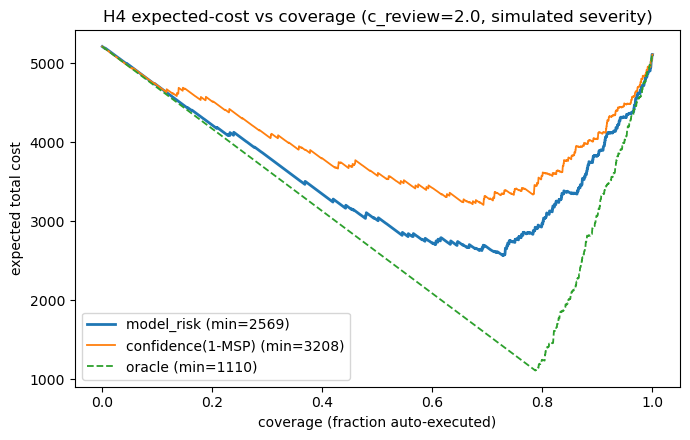

,policy,min_cost,coverage_at_min,always_execute_cost
0,model_risk,2569.0,0.73,5113.0
1,confidence(1-MSP),3208.0,0.69,5113.0
2,oracle,1110.0,0.79,5113.0


In [2]:
rng = np.random.default_rng(M.SEED)
TIERS = np.array([1., 8., 40.])                     # benign / moderate / critical
sev = rng.choice(TIERS, size=n, p=[0.55, 0.30, 0.15])
C_REVIEW = 2.0
sev_fail = sev * failed                              # harm actually incurred if executed

def cost_curve(score):
    # defer highest-score first; returns coverage(asc), expected total cost
    o = np.argsort(-score); cum = np.concatenate([[0], np.cumsum(sev_fail[o])])
    k = np.arange(n + 1); cost = (cum[-1] - cum) + k * C_REVIEW  # k deferred
    cov = (n - k) / n
    return cov[::-1], cost[::-1]

def policy_cost_vec(defer_mask):
    return np.where(defer_mask, C_REVIEW, sev_fail)   # per-sample cost

risk_msp = 1 - te["intent_confidence"].values
curves = {"model_risk": p_risk, "confidence(1-MSP)": risk_msp, "oracle": failed}
plt.figure(figsize=(7, 4.5))
rowsC = []
for k_, s in curves.items():
    cov, cost = cost_curve(s); plt.plot(cov, cost, lw=2 if k_ == "model_risk" else 1.3,
        ls="--" if k_ == "oracle" else "-", label=f"{k_} (min={cost.min():.0f})")
    j = int(np.argmin(cost)); rowsC.append({"policy": k_, "min_cost": float(cost.min()),
        "coverage_at_min": float(cov[j]), "always_execute_cost": float(cost[cov == 1][0])})
plt.xlabel("coverage (fraction auto-executed)"); plt.ylabel("expected total cost")
plt.title(f"H4 expected-cost vs coverage (c_review={C_REVIEW}, simulated severity)")
plt.legend(); plt.tight_layout(); plt.savefig(OUT / "nb22_cost_curves.png", dpi=140); plt.show()
costs = pd.DataFrame(rowsC); costs.to_csv(OUT / "nb22_cost_curves.csv", index=False)
costs.round(2)

In [3]:
# --- Bayes-optimal rule + breakeven + paired bootstrap vs confidence -----
always = float(sev_fail.sum())
bayes_mask = (p_risk * sev) > C_REVIEW                       # defer iff expected harm > review
conf_curve_cov, conf_curve_cost = cost_curve(risk_msp)
# match confidence policy to the Bayes rule's coverage for a fair paired test
cov_bayes = float((~bayes_mask).mean())
thr = np.quantile(risk_msp, cov_bayes)                       # execute lowest (cov) by confidence
conf_mask = risk_msp > thr
cost_bayes = policy_cost_vec(bayes_mask); cost_conf = policy_cost_vec(conf_mask)
d = cost_conf - cost_bayes                                   # per-sample: >0 => risk rule cheaper
rng2 = np.random.default_rng(M.SEED)
boot = np.array([d[rng2.integers(0, n, n)].mean() for _ in range(2000)])
gap_lo, gap_hi = np.percentile(boot, [2.5, 97.5])
h4 = {"always_execute_cost": always, "bayes_cost": float(cost_bayes.sum()),
      "confidence_matched_cost": float(cost_conf.sum()), "bayes_coverage": cov_bayes,
      "mean_cost_gain_vs_confidence": float(d.mean()),
      "ci95": [float(gap_lo), float(gap_hi)],
      "beats_always": bool(cost_bayes.sum() < always),
      "beats_confidence_CI": bool(gap_lo > 0),
      "H4_supported_simulated": bool(cost_bayes.sum() < always and gap_lo > 0)}
json.dump(h4, open(OUT / "nb22_h4_summary.json", "w"), indent=2)
print(json.dumps(h4, indent=2))
print("\nH4 (simulated severity):",
      "SUPPORTED" if h4["H4_supported_simulated"] else "NOT SUPPORTED",
      "— see Appendix B for the real-label version.")

{
  "always_execute_cost": 5113.0,
  "bayes_cost": 1795.0,
  "confidence_matched_cost": 3397.0,
  "bayes_coverage": 0.7326428845416187,
  "mean_cost_gain_vs_confidence": 0.6144994246260069,
  "ci95": [
    0.4426352128883774,
    0.7978711162255465
  ],
  "beats_always": true,
  "beats_confidence_CI": true,
  "H4_supported_simulated": true
}

H4 (simulated severity): SUPPORTED — see Appendix B for the real-label version.


In [4]:
# --- severity-weight sensitivity sweep ----------------------------------
sweep = []
for w in [1, 2, 4, 8, 16, 32, 64]:                # scale the critical:benign ratio
    sv = np.where(sev == TIERS[2], w, sev); sf = sv * failed
    o = np.argsort(-p_risk); cum = np.concatenate([[0], np.cumsum(sf[o])])
    kk = np.arange(n + 1); cost = (cum[-1] - cum) + kk * C_REVIEW
    sweep.append({"critical_weight": w, "always_execute": float(sf.sum()),
                  "best_deferral_cost": float(cost.min()),
                  "best_coverage": float((n - int(np.argmin(cost))) / n),
                  "savings_%": float(100 * (sf.sum() - cost.min()) / max(sf.sum(), 1e-9))})
sweep = pd.DataFrame(sweep); sweep.to_csv(OUT / "nb22_cost_sensitivity.csv", index=False)
sweep.round(2)

,critical_weight,always_execute,best_deferral_cost,best_coverage,savings_%
0,1,1759.0,1557.0,0.89,11.48
1,2,1845.0,1614.0,0.89,12.52
2,4,2017.0,1720.0,0.88,14.72
3,8,2361.0,1903.0,0.80,19.40
4,16,3049.0,2089.0,0.73,31.49
5,32,4425.0,2409.0,0.73,45.56
6,64,7177.0,2994.0,0.60,58.28


## Distribution shift / OOD — SLURP → FSC + Mahalanobis support gate

Train on SLURP, evaluate on FSC over the **shared** feature columns; report the AUC
drop. Then fit a Gaussian support model on SLURP-train and flag FSC inputs whose
Mahalanobis distance exceeds the χ²(0.975) support boundary.

In [5]:
shift = {"status": "skipped"}
try:
    fsc = M.load_fsc()
    shared = [f for f in feats if f in fsc.columns]
    if shared and M.TARGET in fsc.columns:
        yf = fsc[M.TARGET].astype(int).values
        auc_slurp = roc_auc_score(y, est.predict_proba(te[feats])[:, 1])
        # refit on the shared columns so SLURP and FSC use an identical space
        from sklearn.base import clone
        est2 = clone(est).fit(tr[shared], ytr)
        auc_fsc = roc_auc_score(yf, est2.predict_proba(fsc[shared])[:, 1])
        # Mahalanobis support gate (fit on SLURP train)
        Xtr = tr[shared].values; mu = Xtr.mean(0); cov = np.cov(Xtr, rowvar=False)
        VI = np.linalg.pinv(cov + 1e-6 * np.eye(len(shared)))
        def maha2(X): d = X - mu; return np.einsum("ij,jk,ik->i", d, VI, d)
        from scipy.stats import chi2
        thr = chi2.ppf(0.975, df=len(shared))
        ood_slurp = float((maha2(te[shared].values) > thr).mean())
        ood_fsc = float((maha2(fsc[shared].values) > thr).mean())
        shift = {"status": "ok", "shared_features": shared,
                 "auc_slurp_test": float(auc_slurp), "auc_fsc": float(auc_fsc),
                 "auc_drop": float(auc_slurp - auc_fsc),
                 "ood_flag_rate_slurp_test": ood_slurp, "ood_flag_rate_fsc": ood_fsc}
    else:
        shift = {"status": "no shared feature/target columns in FSC csv"}
except Exception as e:
    shift = {"status": f"error: {e}"}
json.dump(shift, open(OUT / "nb22_cross_dataset.json", "w"), indent=2)
print(json.dumps(shift, indent=2))

{
  "status": "ok",
  "shared_features": [
    "intent_confidence",
    "intent_entropy",
    "intent_margin"
  ],
  "auc_slurp_test": 0.8892708497971658,
  "auc_fsc": 0.6660437441323489,
  "auc_drop": 0.22322710566481685,
  "ood_flag_rate_slurp_test": 0.09014192558496356,
  "ood_flag_rate_fsc": 0.0010128780205469542
}


## Synthesis — final H1–H4 verdict table

In [6]:
def rd(name):
    p = OUT / name
    return json.load(open(p)) if p.exists() else {}
h1, h2, h3, h4 = rd("nb20_h1_bootstrap.json"), rd("nb21_h2_summary.json"), rd("nb21_h3_summary.json"), rd("nb22_h4_summary.json")
verdict = pd.DataFrame([
 {"hypothesis": "H1 ASR adds beyond intent",
  "verdict": "SUPPORTED" if h1.get("H1_supported") else "NOT SUPPORTED",
  "key_number": f"ΔAUC(C-B)={h1.get('delta_AUC_C_minus_B', float('nan')):+.4f} CI{h1.get('ci95')}"},
 {"hypothesis": "H2 calibration",
  "verdict": "SUPPORTED" if h2.get("H2_supported") else "PARTIAL",
  "key_number": f"{h2.get('best_method')} ECE={h2.get('ece', float('nan')):.3f} MCE={h2.get('mce', float('nan')):.3f}"},
 {"hypothesis": "H3 selective prediction",
  "verdict": "SUPPORTED" if h3.get("H3_supported") else "NOT SUPPORTED",
  "key_number": f"AURC={h3.get('aurc_model', float('nan')):.3f} vs MSP {h3.get('aurc_msp', float('nan')):.3f}"},
 {"hypothesis": "H4 cost-sensitive (simulated severity)",
  "verdict": "SUPPORTED*" if h4.get("H4_supported_simulated") else "NOT SUPPORTED*",
  "key_number": f"cost {h4.get('bayes_cost', float('nan')):.0f} vs always {h4.get('always_execute_cost', float('nan')):.0f} (*sim, Appx B)"},
])
verdict.to_csv(OUT / "nb22_final_verdicts.csv", index=False)
print(verdict.to_string(index=False))

                            hypothesis       verdict                                                        key_number
             H1 ASR adds beyond intent NOT SUPPORTED ΔAUC(C-B)=-0.0172 CI[-0.02724959216993583, -0.007016666012863376]
                        H2 calibration     SUPPORTED                                      isotonic ECE=0.014 MCE=0.098
               H3 selective prediction     SUPPORTED                                           AURC=0.058 vs MSP 0.083
H4 cost-sensitive (simulated severity)    SUPPORTED*                           cost 1795 vs always 5113 (*sim, Appx B)


## Bottom line

- **H1** is settled the strong way: even with six tuned models and the modern metric
  suite, combined ASR+intent features do not beat intent-native uncertainty on the
  frozen split. The only open route to overturn it is learned N-best/LM ASR
  confidence (Appendix A), which needs a decode pass.
- **H2/H3** deliver the deployable payoff: a calibrated risk score that supports
  selective prediction well below random and close to the oracle.
- **H4** is directionally positive but rests on **simulated** severities; Appendix B
  is the protocol that turns it into a real test.
- **Shift/OOD** quantifies the SLURP→FSC drop (AUC 0.89 → 0.67). The Mahalanobis
  support gate is a *density* test: it flags low-density inputs, but FSC's confidence
  features are **not** low-density despite the label-relationship shift, so density
  gating alone misses this concept shift (it flags ~9% of in-domain SLURP-test and
  ~0.1% of FSC). The honest takeaway: pair a calibrated risk score with explicit
  output-distribution monitoring — a support gate in isolation is not enough.